# Memory Recall

Load a trained TPC run, recover the exact preloaded training trajectories it used, and compare stored vs recalled trajectories in the 2D environment.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repo_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for cand in candidates:
        if (cand / "src").exists() and (cand / "results").exists():
            return cand
    raise RuntimeError("Could not locate repo root from current working directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data.place_cells import PlaceCells
from src.data.preload_data import Trjectory, get_traj_data_path
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import HierarchicalPCN, TemporalPCN
from src.trainer import PCTrainer


def load_run_options(dt, model="tpc"):
    run_dir = REPO_ROOT / "results" / model / dt
    cfg = json.loads((run_dir / "configs.json").read_text())
    options = SimpleNamespace(**cfg)
    options.device = "cuda" if torch.cuda.is_available() else "cpu"
    options.save_dir = str(run_dir)
    options.sweep = True
    options.oned = getattr(options, "oned", False)
    return options, run_dir


def load_tpc_trainer(dt):
    options, run_dir = load_run_options(dt, model="tpc")
    place_cells = PlaceCells(options)
    generator = TrajectoryGenerator(options, place_cells, environment=options.env_shape)

    model = TemporalPCN(options).to(options.device)
    init_model = HierarchicalPCN(options).to(options.device)
    ckpt = torch.load(run_dir / "models" / "most_recent_model.pth", map_location=options.device)
    model.load_state_dict(ckpt["model"])
    init_model.load_state_dict(ckpt["init_model"])

    trainer = PCTrainer(options, model, init_model, generator, place_cells)
    return options, run_dir, place_cells, trainer


def load_eval_dataset(options, place_cells=None, eval_dataset_mode="training", eval_dataset_path=None):
    if eval_dataset_mode == "training":
        rel_path = Path(get_traj_data_path(options))
        abs_path = REPO_ROOT / rel_path
    elif eval_dataset_mode == "external":
        if eval_dataset_path is None:
            raise ValueError("eval_dataset_path must be provided when eval_dataset_mode='external'")
        abs_path = Path(eval_dataset_path)
        if not abs_path.is_absolute():
            abs_path = (REPO_ROOT / abs_path).resolve()
    else:
        raise ValueError("eval_dataset_mode must be 'training' or 'external'")

    if not abs_path.exists():
        raise FileNotFoundError(f"Evaluation dataset not found: {abs_path}")

    ds = Trjectory(str(abs_path))
    v = torch.tensor(np.asarray(ds.v), dtype=torch.float32)
    init_actv = torch.tensor(np.asarray(ds.init_actv), dtype=torch.float32)
    if getattr(ds, "init_pos", None) is not None:
        init_pos = torch.tensor(np.asarray(ds.init_pos), dtype=torch.float32)
    else:
        if place_cells is None:
            raise ValueError("place_cells must be provided when init_pos is missing from dataset")
        init_pos = place_cells.get_nearest_cell_pos(init_actv.unsqueeze(1), k=3).squeeze(1).detach().cpu()
    pc_outputs = torch.tensor(np.asarray(ds.pc_outputs), dtype=torch.float32)
    pos = torch.tensor(np.asarray(ds.pos), dtype=torch.float32)
    return abs_path, (v, init_actv), init_pos, pc_outputs, pos


def recall_positions(trainer, place_cells, inputs, init_pos, pc_outputs, pos, use_velocity=None, cue_step=1):
    v, init_actv = inputs
    if use_velocity is None:
        use_velocity = not bool(getattr(trainer.options, "no_velocity", False))

    seq_len = v.shape[1]
    if cue_step < 1 or cue_step >= seq_len:
        raise ValueError(f"cue_step must be in [1, {seq_len - 1}], got {cue_step}")

    v_cue = v[:, :cue_step]
    p_cue = pc_outputs[:, :cue_step]
    v_eval = v[:, cue_step:]
    if not use_velocity:
        v_cue = torch.zeros_like(v_cue)
        v_eval = torch.zeros_like(v_eval)

    trainer.model.eval()
    trainer.init_model.eval()
    with torch.no_grad():
        trainer.init_model.inference(
            trainer.test_inf_iters,
            trainer.inf_lr,
            init_actv.to(trainer.options.device),
        )
        prev_hidden = trainer.init_model.z.clone().detach()
        pred_zs_prefix = [prev_hidden]
        pred_xs_prefix = [trainer.init_model.decode(prev_hidden)]

        # Use true place-cell cues for the first cue_step steps to set the recurrent state.
        for k in range(v_cue.shape[1]):
            vk = v_cue[:, k].to(trainer.options.device)
            pk = p_cue[:, k].to(trainer.options.device)
            trainer.model.inference(
                trainer.test_inf_iters,
                trainer.inf_lr,
                vk,
                prev_hidden,
                pk,
            )
            prev_hidden = trainer.model.z.clone().detach()
            pred_zs_prefix.append(prev_hidden)
            pred_xs_prefix.append(trainer.model.decode(prev_hidden))

        pred_zs = []
        for k in range(v_eval.shape[1]):
            vk = v_eval[:, k].to(trainer.options.device)
            prev_hidden = trainer.model.g(vk, prev_hidden)
            pred_zs.append(prev_hidden)

        if len(pred_zs) > 0:
            pred_zs_rollout = torch.stack(pred_zs, dim=1)
            pred_xs_rollout = trainer.model.decode(pred_zs_rollout)
        else:
            pred_zs_rollout = torch.empty((v.shape[0], 0, prev_hidden.shape[-1]), device=prev_hidden.device)
            pred_xs_rollout = torch.empty((v.shape[0], 0, trainer.place_cells.Np), device=prev_hidden.device)

        pred_zs_prefix = torch.stack(pred_zs_prefix, dim=1)
        pred_xs_prefix = torch.stack(pred_xs_prefix, dim=1)
        pred_zs_full = torch.cat([pred_zs_prefix, pred_zs_rollout], dim=1)
        pred_xs_full = torch.cat([pred_xs_prefix, pred_xs_rollout], dim=1)

    pred_pos_model = place_cells.get_nearest_cell_pos(pred_xs_full, k=3).detach().cpu()
    target_pos = torch.cat([init_pos.unsqueeze(1), pos], dim=1).detach().cpu()
    pred_pos = pred_pos_model.clone()
    pred_pos[:, : cue_step + 1] = target_pos[:, : cue_step + 1]
    return target_pos, pred_pos, pred_xs_full.detach().cpu(), pred_zs_full.detach().cpu()


def trajectory_mse(target_pos, pred_pos):
    return ((target_pos - pred_pos) ** 2).mean().item()


def plot_recall_trajectories(target_pos, pred_pos, options, cue_step, sample_ids=None, n_show=9, title=None):
    target_np = target_pos.detach().cpu().numpy()
    pred_np = pred_pos.detach().cpu().numpy()

    n_total = target_np.shape[0]
    if sample_ids is None:
        n_show = min(n_show, n_total)
        sample_ids = np.arange(n_show)
    else:
        sample_ids = np.asarray(sample_ids)

    n_show = len(sample_ids)
    ncols = min(3, n_show)
    nrows = int(np.ceil(n_show / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.0 * nrows), squeeze=False)
    axes = axes.ravel()

    for ax, idx in zip(axes, sample_ids):
        gt = target_np[idx]
        pr = pred_np[idx]

        ax.plot(gt[:, 0], gt[:, 1], color="black", lw=2, label="Original")
        cue_end = cue_step + 1
        ax.plot(
            pr[:cue_end, 0],
            pr[:cue_end, 1],
            color="crimson",
            lw=1.8,
            ls="--",
            alpha=0.9,
            label="Cue",
        )
        if cue_end < len(pr):
            ax.plot(
                pr[cue_end - 1 :, 0],
                pr[cue_end - 1 :, 1],
                color="crimson",
                lw=1.8,
                alpha=0.9,
                label="Recall",
            )
        ax.scatter(gt[0, 0], gt[0, 1], color="black", s=35)
        ax.scatter(pr[0, 0], pr[0, 1], color="crimson", s=35)

        mse_i = ((gt - pr) ** 2).mean()
        ax.set_title(f"Trajectory {idx} | MSE={mse_i:.4e}")
        ax.set_xlim(-options.box_width / 2, options.box_width / 2)
        ax.set_ylim(-options.box_height / 2, options.box_height / 2)
        ax.set_aspect("equal")
        ax.grid(alpha=0.25, linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if idx == 0:
            ax.legend()

    for ax in axes[n_show:]:
        ax.axis("off")

    # handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    if title is not None:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## Run Selection

Set the run timestamp and inspect the exact preloaded dataset used during training.

In [14]:
dt = "May-03-2026-09-09-16"  # replace with your run folder name
# eval_dataset_mode = "external"  # 'training' or 'external'
eval_dataset_mode = "training"
# eval_dataset_path = 'data/trajectory/3_10_512_[005]_rectangle_seed1.npz'  # e.g. 'data/trajectory/10_10_512_002_rectangle_seed0.npz'
eval_dataset_path =None
use_velocity = None  # None -> infer from run config; set True/False to override
cue_step = 1  # number of true sequence steps used as cues after init_model; must be >= 1
n_show = 9
sample_ids = None  # e.g. [0, 1, 2]

options, run_dir, place_cells, trainer = load_tpc_trainer(dt)
dataset_path, inputs, init_pos, pc_outputs, pos = load_eval_dataset(
    options,
    place_cells=place_cells,
    eval_dataset_mode=eval_dataset_mode,
    eval_dataset_path=eval_dataset_path,
)
target_pos, pred_pos, pred_xs, pred_zs = recall_positions(
    trainer,
    place_cells,
    inputs,
    init_pos,
    pc_outputs,
    pos,
    use_velocity=use_velocity,
    cue_step=cue_step,
)
effective_use_velocity = not bool(options.no_velocity) if use_velocity is None else bool(use_velocity)

print(f"Run directory: {run_dir}")
print(f"Evaluation dataset mode: {eval_dataset_mode}")
print(f"Evaluation dataset: {dataset_path}")
print(f"Run config no_velocity: {options.no_velocity}")
print(f"Recall evaluated with velocity: {effective_use_velocity}")
print(f"Cue step: {cue_step}")
print(f"Total trajectories: {pos.shape[0]}")
print(f"Original sequence length: {pos.shape[1]}")
print(f"Full plotted sequence length: {target_pos.shape[1]}")
print(f"Recall MSE: {trajectory_mse(target_pos, pred_pos):.6e}")


Run directory: C:\Users\User\projects\place-cell-pred-coding\results\tpc\May-03-2026-09-09-16
Evaluation dataset mode: training
Evaluation dataset: C:\Users\User\projects\place-cell-pred-coding\data\trajectory\3_10_512_[005]_rectangle_seed1.npz
Run config no_velocity: False
Recall evaluated with velocity: True
Cue step: 1
Total trajectories: 3
Original sequence length: 10
Full plotted sequence length: 11
Recall MSE: 9.344187e-04


In [15]:
pred_pos.shape, target_pos.shape

(torch.Size([3, 11, 2]), torch.Size([3, 11, 2]))

## Original and Recalled Trajectories

Black curves are stored training trajectories. Crimson curves are model recall from the same initial place-cell cue, with the stored velocity sequence optionally provided.

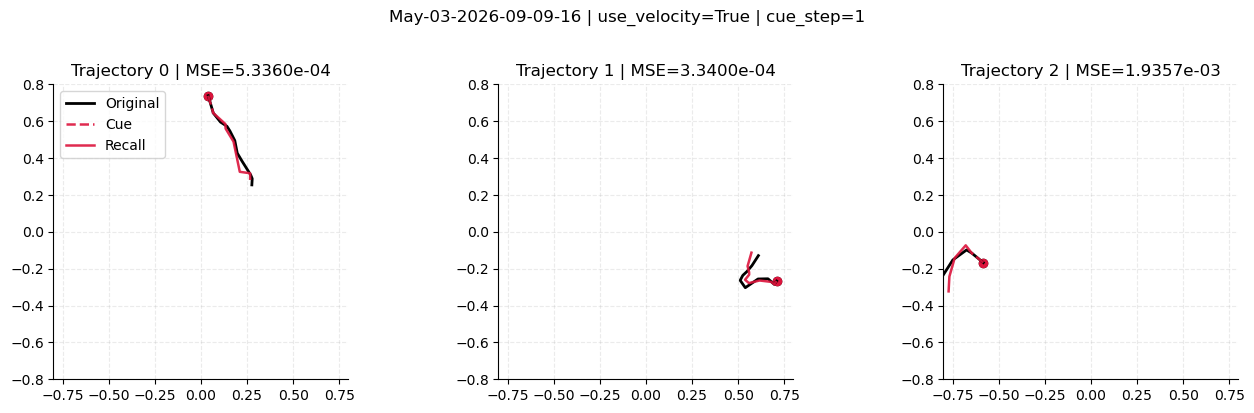

In [16]:
plot_recall_trajectories(
    target_pos,
    pred_pos,
    options,
    cue_step=cue_step,
    sample_ids=sample_ids,
    n_show=n_show,
    title=f"{dt} | use_velocity={effective_use_velocity} | cue_step={cue_step}",
)


In [167]:
pred_pos

tensor([[[0.0392, 0.7380],
         [0.1363, 0.7048],
         [0.2642, 0.7627],
         [0.3039, 0.7705],
         [0.3039, 0.7705],
         [0.3468, 0.7795],
         [0.3468, 0.7795],
         [0.3468, 0.7795],
         [0.3636, 0.7766],
         [0.3636, 0.7766],
         [0.3636, 0.7766]]], dtype=torch.float64)